# Machine Learning in Python - Project

Due Friday, Apr 10th by 4 pm.

**B300238** Darren Lim, **B296110** Ming Cen

## Setup

All libraries are imported below. A single `RANDOM_STATE` constant ensures reproducibility throughout. The scikit-learn library [1] is used for all preprocessing, modelling, and evaluation components.

In [1]:
# Core data libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# sklearn: data splitting & pipelines
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# sklearn: preprocessing
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

# sklearn: models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# sklearn: evaluation
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, f1_score,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)

# UMAP (class-separability diagnostic)
import umap

# Ignore INFO, WARNING, ERROR logs
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings('ignore')

# Global constants
RANDOM_STATE = 11205 # fixed seed for all stochastic operations
FEAT_MISS_THRESH = 0.40 # drop features with >40% missing
ROW_MISS_THRESH = 0.20 # drop rows with >20% missing
CORR_THRESH = 0.005 # minimum |Pearson r| to retain a feature

# Plot aesthetics
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')
BLUE = '#5B9BD5'
ORANGE = '#ED7D31'
print("Setup complete.")

2026-04-04 00:06:57.687554: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-04 00:06:57.711353: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-04 00:06:58.493389: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-04 00:07:00.782980: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

Setup complete.


# 1. Introduction

Mental health in children is a pressing global public health priority. Depression in early life impairs educational attainment, social development, and long-term economic productivity, and these effects are disproportionately concentrated in low- and middle-income countries (LMICs) where access to screening, diagnosis, and treatment remains severely constrained [2].

This report presents a binary classification analysis of childhood depressive symptoms using the UNICEF Multiple Indicator Cluster Survey (MICS) conducted in Malawi in 2019–2020 [3,4]. The dataset integrates information from three linked questionnaires (child-level, maternal, and household) yielding a rich, multi-domain feature set of **82 candidate predictors** spanning child demographics, labour participation, discipline practices, maternal well-being, household infrastructure, and socioeconomic status. After feature engineering (four domain-motivated composite features added) and removal of one high-missingness variable, **85 features** are retained for modelling. After removing records with missing or non-valid responses on the target variable, 13,036 observations are available for analysis.

**Target variable:** The survey item *"How often does the child seem very sad or depressed?"* (FCF26) yields five ordered response categories: *never*, *a few times a year*, *monthly*, *weekly*, and *daily*. To facilitate binary discrimination between no depression and any form of depression, these are binarised: *never* is coded as **no depression** (0) and all other responses as **depression** (1). It is acknowledged that this collapses meaningful severity gradations into a single positive class. This yields a near-balanced binary outcome, with approximately 54.7% of children classified as depressed. The heterogeneity of the depressed class, ranging from mild episodic sadness to daily chronic depression, is noted as a methodological limitation.

**Analytical approach:** The analysis proceeds in three stages. Firstly, exploratory data analysis (EDA) and feature engineering are used to assess data quality, visualise key predictor–outcome relationships, and construct a principled, leakage-free preprocessing pipeline incorporating ordinal and nominal encoding, imputation, standardisation, and correlation-based feature selection. Secondly, a **Logistic Regression** baseline and a tuned **Random Forest** classifier are fit, with hyperparameters selected exclusively via cross-validation on the training set and final performance evaluated on a held-out test set. Thirdly, feature importances and model coefficients are interpreted in terms of their real-world significance, and the findings are translated into policy-relevant recommendations.

The analysis finds that the two models achieve modest but genuine discriminative ability (test ROC-AUC ~ 0.63–0.64), consistent with the inherently multidetermined and weakly separable nature of the outcome. Household socioeconomic status, maternal well-being, and exposure to harsh discipline emerge as the most consistent predictors across both models, suggesting clear targets for preventive intervention.

# 2. Exploratory Data Analysis and Feature Engineering

## 2.1 Data Loading and Target Construction

The raw dataset is loaded and the working sample is constructed by removing the 126 records (<1% of the total) where the target variable FCF26 is either missing or carries the value 'NO RESPONSE'. Four cluster-identifier columns (HH1, HH2, LN, FS4) that carry no predictive signal are also dropped, along with the original FCF26 column after the binary target has been created. Two Boolean indicator columns (CL2, CL12) are converted to integers for downstream compatibility with sklearn.

In [2]:
# Load raw data
df_raw = pd.read_csv('unicef_malawi.csv')
print(f"Raw dataset shape: {df_raw.shape}")

# Target binarisation
# FCF26 scale: NEVER / A FEW TIMES A YEAR / MONTHLY / WEEKLY / DAILY
# Binarisation: NEVER = 0 (no depression), all others = 1 (depression)
df = df_raw[df_raw['FCF26'].notna() & (df_raw['FCF26'] != 'NO RESPONSE')].copy()
df['depression'] = (df['FCF26'] != 'NEVER').astype(int)

# Drop identifiers and original target
ID_COLS = ['HH1', 'HH2', 'LN', 'FS4', 'FCF26']
df.drop(columns=ID_COLS, inplace=True)

# Convert boolean columns stored as objects
df['CL2'] = df['CL2'].astype(int)
df['CL12'] = df['CL12'].astype(int)

print(f"Working dataset shape: {df.shape}")
print(f"\nTarget distribution (training sample):")
print(df['depression'].value_counts().rename({0: 'No Depression (0)', 1: 'Depression (1)'}))
print(f"\nDepression prevalence: {df['depression'].mean():.1%}")

Raw dataset shape: (13162, 87)
Working dataset shape: (13036, 83)

Target distribution (training sample):
depression
Depression (1)       7131
No Depression (0)    5905
Name: count, dtype: int64

Depression prevalence: 54.7%


## 2.2 Train / Test Split

The dataset is partitioned into training (85%) and test (15%) subsets using stratified sampling to preserve class proportions across both partitions. This split is performed before any EDA, feature engineering, or preprocessing, ensuring that no information from the test set influences any modelling decision. All EDA, feature engineering decisions, and preprocessing parameters are derived from the training set only. The test set is kept entirely unseen until final model evaluation. Hyperparameter selection for both models is performed exclusively via five-fold stratified cross-validation on the training set.

In [3]:
# Stratified 85 / 15 split
X = df.drop(columns='depression')
y = df['depression']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} rows | {y_train.mean():.1%} depressed")
print(f"Test set:     {X_test.shape[0]:,} rows | {y_test.mean():.1%} depressed")

# Keep a copy of raw training data aligned with y for EDA plots
train_eda = X_train.copy()
train_eda_raw = df_raw.loc[X_train.index].copy()  # for original FCF26 counts
train_eda['depression'] = y_train.values

Training set: 11,080 rows | 54.7% depressed
Test set:     1,956 rows | 54.7% depressed


## 2.3 Target Variable Distribution

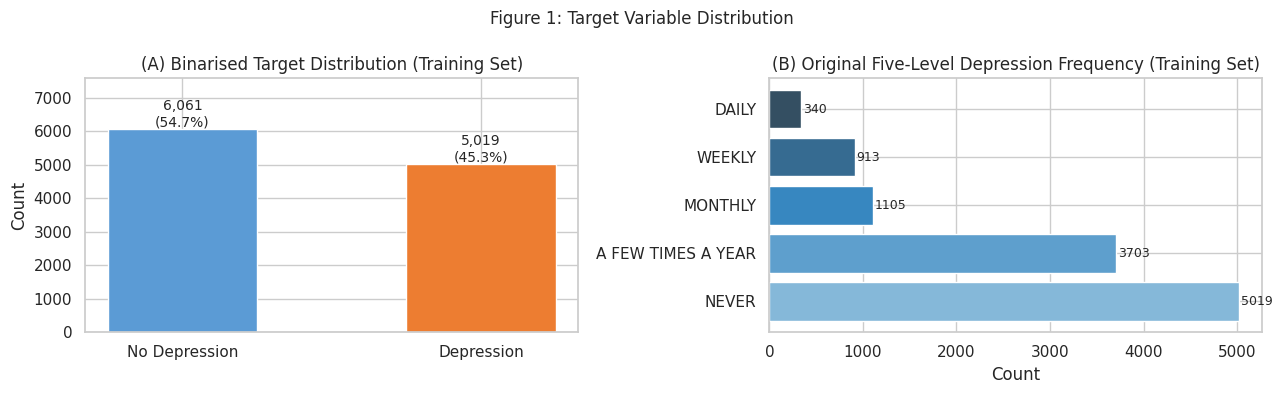

In [4]:
# Figure 1: Target distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel A — binarised target
ax = axes[0]
counts = y_train.value_counts().rename({0: 'No Depression', 1: 'Depression'}).sort_index()
ax.bar(counts.index, counts.values, color=[BLUE, ORANGE], edgecolor='white', width=0.5)
ax.set_title('(A) Binarised Target Distribution (Training Set)')
ax.set_ylabel('Count')
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Depression', 'Depression'])
for i, v in enumerate(counts.values):
    ax.text(i, v + 80, f'{v:,}\n({v/len(y_train):.1%})', ha='center', fontsize=10)
ax.set_ylim(0, counts.max() * 1.25)
ax.set_xlabel('')

# Panel B — original five-level frequency
ax = axes[1]
order = ['NEVER', 'A FEW TIMES A YEAR', 'MONTHLY', 'WEEKLY', 'DAILY']
fcf_train = train_eda_raw['FCF26'].value_counts().reindex(order).dropna()
ax.barh(fcf_train.index, fcf_train.values,
        color=sns.color_palette('Blues_d', len(fcf_train)), edgecolor='white')
ax.set_title('(B) Original Five-Level Depression Frequency (Training Set)')
ax.set_xlabel('Count')
for i, v in enumerate(fcf_train.values):
    ax.text(v + 20, i, str(int(v)), va='center', fontsize=9)

fig.suptitle('Figure 1: Target Variable Distribution',
              fontsize=12)
plt.tight_layout()
plt.show()

**Figure 1.** Target variable distributions in the training set. **(A)** Binarised outcome: the dataset is near-balanced, with 54.7% of children classified as depressed and 45.3% as not depressed. **(B)** Original five-level response distribution: the majority of children report sadness only *a few times a year*, while daily depression is the least common category.

## 2.4 Non-Substantive Value Recoding

Survey questionnaires routinely produce response codes that denote refusal, ignorance, or inapplicability, with values such as "DK" (don't know), "NOT ASKED", or "REFUSED". These carry no substantive information, and are replaced with `NaN` before any further processing.

In [5]:
# Replace non-substantive strings with NaN
NON_SUBSTANTIVE = [
    "NO RESPONSE", "DK", "DON'T KNOW", "DONT KNOW", "DK / NO OPINION",
    "MISSING", "NOT ASKED", "REFUSED", "NO ANSWER", "UNKNOWN"
]

total_replaced = 0
for split in [X_train, X_test]:
    before = (split.isin(NON_SUBSTANTIVE)).sum().sum()
    split.replace(NON_SUBSTANTIVE, np.nan, inplace=True)
    total_replaced += before

print(f"Total non-substantive values recoded to NaN: {total_replaced:,}")

Total non-substantive values recoded to NaN: 2,050


## 2.5 Numeric Type Coercion

Four variables (CL13, MA2, LS2, WS4) were imported as string objects, despite containing numeric information. These columns are coerced to float, and any residual non-numeric strings are silently converted to `NaN` via `errors='coerce'`.

In [6]:
# Coerce string-encoded numeric columns
NUMERIC_COERCE_COLS = ['CL13', 'MA2', 'LS2', 'WS4']

num_before = X_train.select_dtypes(include=np.number).shape[1]
for col in NUMERIC_COERCE_COLS:
    for split in [X_train, X_test]:
        if col in split.columns:
            split[col] = pd.to_numeric(split[col], errors='coerce')
num_after = X_train.select_dtypes(include=np.number).shape[1]

print(f"Numeric columns before coercion: {num_before}")
print(f"Numeric columns after coercion:  {num_after}  (+{num_after - num_before} converted)")

Numeric columns before coercion: 8
Numeric columns after coercion:  12  (+4 converted)


## 2.6 Derived Feature Engineering

Four new features are constructed from the raw variables before any columns are dropped, ensuring that information from high-missingness variables (particularly CL3, child labour hours) is retained in derived form. Each feature captures a domain-theoretic construct not directly observable in the raw survey items.

- `total_children` is constructed from `CSURV + CDEAD` to capture cumulative family burden, including bereavement.
- `child_labour_flag` is constructed from `1 if CL3 > 0, else 0`, a binary indicator of any labour participation, to preserve the key qualitative signal from CL3 before it is dropped due to high missingness.
- `wealth_age` is constructed from `wscore x CB3`, wealth x age interaction term. Poverty effects on mental health compound with developmental stage [2].
- `discipline_score` is constructed from count of harsh methods among FCD2D, FCD2E, and FCD2F, motivated by dose-response evidence for physical discipline and internalising symptoms [5].

These features are applied identically to all three data partitions.

In [7]:
# Construct derived features (applied before column drop)
def add_derived_features(df_part):
    """Add four domain-driven engineered features to a data partition."""
    df_part = df_part.copy()
    # 1. Total family burden: surviving + deceased children
    df_part['total_children'] = (
        df_part['CSURV'].fillna(0) + df_part['CDEAD'].fillna(0)
    )
    # 2. Child labour indicator — derived before CL3 is dropped
    df_part['child_labour_flag'] = (
        df_part['CL3'].fillna(0) > 0
    ).astype(int)
    # 3. Wealth × Age interaction
    df_part['wealth_age'] = df_part['wscore'] * df_part['CB3']
    # 4. Harsh discipline composite (count of YES responses across 3 items)
    harsh_cols = ['FCD2D', 'FCD2E', 'FCD2F']
    score = pd.Series(0, index=df_part.index)
    for col in harsh_cols:
        if col in df_part.columns:
            score += (
                df_part[col].astype(str).str.upper().str.strip()
                .isin(['YES', '1', 'TRUE']).astype(int)
            )
    df_part['discipline_score'] = score
    return df_part

X_train = add_derived_features(X_train)
X_test = add_derived_features(X_test)

# Update EDA frame
train_eda = X_train.copy()
train_eda['depression'] = y_train.values

print("Engineered features summary (training set):")
print(f"  total_children     — mean: {X_train['total_children'].mean():.2f}")
print(f"  child_labour_flag  — proportion in labour: {X_train['child_labour_flag'].mean():.1%}")
print(f"  wealth_age         — mean: {X_train['wealth_age'].mean():.2f}")
print(f"  discipline_score   — mean: {X_train['discipline_score'].mean():.2f}  (range 0–3)")

Engineered features summary (training set):
  total_children     — mean: 4.12
  child_labour_flag  — proportion in labour: 24.1%
  wealth_age         — mean: 0.64
  discipline_score   — mean: 1.33  (range 0–3)


## 2.7 Missing Data Analysis and Filtering

Missing data arise for several structural reasons in this survey dataset. Some variables are conditional on prior responses (e.g. CL3, child labour hours, is asked only of children currently engaged in labour, making it structurally missing for the majority), while others reflect genuine non-response or routing logic. Visual inspection of missingness rates guides two removal decisions.

**Feature removal:** Following the recommendation that a missing data proportion exceeding 40% in a feature typically indicates a variable unsuitable for standard imputation strategies [6,7], features with more than 40% missing values in the training set are dropped. Only CL3 (68.3% missing) exceeds this threshold, and its key signal has already been captured by `child_labour_flag`.

**Row removal:** Rows in which more than 20% of feature values are missing are dropped from all three partitions. Missing values in rows below this threshold are subsequently handled by imputation within the preprocessing pipeline. Critically, both thresholds are determined exclusively on the training set, and the resulting column and row indices are then applied to the validation and test sets without refitting.

In [8]:
# Top-5 feature missingness rates
missing_rate_train = X_train.isna().mean().sort_values(ascending=False)
top10_miss = missing_rate_train.head(5)
print(top10_miss)
print(f"Features with > {FEAT_MISS_THRESH:.0%} missing: "
      f"{(missing_rate_train > FEAT_MISS_THRESH).sum()}")

# Apply feature drop (threshold determined on training set only)
keep_cols = missing_rate_train[missing_rate_train <= FEAT_MISS_THRESH].index
n_feat_before = X_train.shape[1]
X_train = X_train[keep_cols].copy()
X_test = X_test[keep_cols].copy()
print(f"Features: {n_feat_before} -> {X_train.shape[1]}  "
      f"(dropped: {n_feat_before - X_train.shape[1]})")

# Apply row drop
def apply_row_filter(X, y, threshold=ROW_MISS_THRESH):
    keep = X.isna().mean(axis=1) <= threshold
    return X.loc[keep].copy(), y.loc[keep].copy(), keep.sum()

X_train, y_train, n_tr = apply_row_filter(X_train, y_train)
X_test, y_test, n_te = apply_row_filter(X_test,  y_test)

print(f"\nRows after {ROW_MISS_THRESH:.0%} row filter:")
print(f"  Train: {n_tr:,}  |  Test: {n_te:,}")

# Refresh EDA frame after row filter
train_eda = X_train.copy()
train_eda['depression'] = y_train.values

CL3     0.683303
FCD5    0.379874
HW5     0.263538
MA2     0.238267
MA3     0.225181
dtype: float64
Features with > 40% missing: 1
Features: 86 -> 85  (dropped: 1)

Rows after 20% row filter:
  Train: 10,805  |  Test: 1,893


## 2.8 Ordinal Variable Cleaning and Category Merging

Thirteen variables are identified as ordinal, which measure constructs with a meaningful natural order but unequal or unknown interval spacing. These require preprocessing that preserves rank structure while reducing unnecessary sparsity from rare or overlapping categories. A `clean_merge_ordinal()` function is applied uniformly to all three data partitions.

The key transformations are: (1) recoding genuinely non-applicable responses as missing (e.g. 'NEVER WALK ALONE AFTER DARK' in the safety perception variables VT20 and VT21, which is not a position on the safety scale), (2) merging educationally rare upper-level categories (e.g. 'HIGHER' education absorbed into 'UPPER SECONDARY' for child's school level, where fewer than 0.5% of observations fall in the highest tier), (3) collapsing 'A LOT OF DIFFICULTY' with 'SOME DIFFICULTY' for the maternal functioning variables AF11 and AF12, where the 'A LOT' category contains fewer than 15 observations in the training set, and (4) standardising grade label strings for consistency with the encoder's category list.

In [9]:
# Define ordinal candidates
ORDINAL_CANDIDATES = [
    'CB5A', 'CB5B',          # child's current school level and grade
    'WB6A', 'WB6B',          # mother's education level and grade
    'WB14',                  # mother's literacy
    'AF10', 'AF11', 'AF12',  # maternal functioning difficulties
    'LS1', 'LS3', 'LS4',     # life satisfaction (level, vs 1yr ago, vs 1yr ahead)
    'VT20', 'VT21'          # perceived safety walking alone at night
]
ordinal_cols = [c for c in ORDINAL_CANDIDATES if c in X_train.columns]

def clean_merge_ordinal(df_in, cols):
    """Recode non-applicable responses and merge rare/overlapping categories."""
    df_out = df_in.copy()
    grade_map = {f"CLASS/YEAR/GRADE {i}": f"GRADE {i}" for i in range(1, 9)}
    grade_map.update({"CLASS/GRADE 6": "GRADE 6",
                       "CLASS/GRADE 7": "GRADE 7",
                       "CLASS/GRADE 8": "GRADE 8"})
    # Non-applicable -> NaN
    if 'WB14' in cols:
        df_out['WB14'] = df_out['WB14'].replace(
            {'NO SENTENCE IN REQUIRED LANGUAGE / BRAILLE': np.nan})
    for v in ('VT20', 'VT21'):
        if v in cols:
            df_out[v] = df_out[v].replace({'NEVER WALK ALONE AFTER DARK': np.nan})
    # Merge rare upper education tier
    if 'CB5A' in cols:
        df_out['CB5A'] = df_out['CB5A'].replace({'HIGHER': 'UPPER SECONDARY'})
    if 'WB6A' in cols:
        df_out['WB6A'] = df_out['WB6A'].replace(
            {'ECE': 'PRIMARY', 'VOCATIONAL TRAINING': 'UPPER SECONDARY'})
    # Collapse very small difficulty categories
    for v in ('AF11', 'AF12'):
        if v in cols:
            df_out[v] = df_out[v].replace({'A LOT OF DIFFICULTY': 'SOME DIFFICULTY'})
    # Standardise grade labels
    if 'CB5B' in cols: df_out['CB5B'] = df_out['CB5B'].replace(grade_map)
    if 'WB6B' in cols: df_out['WB6B'] = df_out['WB6B'].replace(grade_map)
    return df_out[cols]

for split in [X_train, X_test]:
    split[ordinal_cols] = clean_merge_ordinal(split, ordinal_cols)

# Show after for three key variables
print("Category counts after merging (training set):")
for col in ['CB5A', 'WB6A', 'AF11']:
    print(f"\n  {col}:")
    print(f"  {X_train[col].value_counts(dropna=False).to_dict()}")

Category counts after merging (training set):

  CB5A:
  {'PRIMARY': 9159, nan: 712, 'ECE': 503, 'LOWER SECONDARY': 305, 'UPPER SECONDARY': 126}

  WB6A:
  {'PRIMARY': 7308, nan: 1300, 'LOWER SECONDARY': 1097, 'UPPER SECONDARY': 922, 'HIGHER': 178}

  AF11:
  {'NO DIFFICULTY': 10612, 'SOME DIFFICULTY': 185, nan: 8}


## 2.9 Nominal Variable Cleaning and Category Merging

Six variables are treated as nominal, which have no inherent order. Merging semantically similar categories reduces one-hot encoding sparsity and prevents individual rare categories from receiving zero or near-zero weight estimates. All groupings are made on substantive public health grounds rather than statistical convenience.

For drinking water source (WS1), categories are collapsed to three tiers that reflect the WHO/UNICEF Joint Monitoring Programme hierarchy: piped water (highest safety), groundwater (boreholes, protected/unprotected wells and springs), and other water (surface, delivered, purchased, or rainwater). Sanitation facility type (WS11) is similarly collapsed by upgrade level. Floor (HC4) and roof (HC5) materials are grouped into 'basic' and 'finished' tiers, following the established convention for housing quality as a poverty proxy [3]. Ethnicity categories with very low frequency are grouped to prevent near-zero class support in the one-hot encoded matrix.

In [10]:
# Define nominal candidates
NOMINAL_CANDIDATES = ['WS1', 'WS11', 'HC5', 'HC4', 'ethnicity', 'WS3']
nominal_candidates = [c for c in NOMINAL_CANDIDATES if c in X_train.columns]

def clean_merge_nominal(df_in, cols):
    """Group nominal categories by substantive meaning to reduce sparsity.
    WS1: piped/groundwater/other (WHO-JMP hierarchy)
    WS11: flush/improved pit/open pit/other sanitation
    HC4: basic vs finished floor
    HC5: basic vs finished roof
    ethnicity: rare categories pooled
    WS3: left as-is
    """
    df_out = df_in.copy()
    if 'WS1' in cols:
        ws1 = {
            'PIPED WATER: PIPED INTO DWELLING': 'PIPED WATER',
            'PIPED WATER: PIPED TO YARD / PLOT': 'PIPED WATER',
            'PIPED WATER: PIPED TO NEIGHBOUR': 'PIPED WATER',
            'PIPED WATER: PUBLIC TAP / STANDPIPE': 'PIPED WATER',
            'TUBE WELL / BOREHOLE': 'GROUNDWATER',
            'DUG WELL: PROTECTED WELL': 'GROUNDWATER',
            'DUG WELL: UNPROTECTED WELL': 'GROUNDWATER',
            'SPRING: PROTECTED SPRING': 'GROUNDWATER',
            'SPRING: UNPROTECTED SPRING': 'GROUNDWATER',
            'SURFACE WATER (RIVER, DAM, LAKE, POND, STREAM, CANAL, IRRIGATION CHANNEL)': 'OTHER WATER',
            'CART WITH SMALL TANK': 'OTHER WATER',
            'TANKER-TRUCK': 'OTHER WATER',
            'PACKAGED WATER: BOTTLED WATER': 'OTHER WATER',
            'WATER KIOSK': 'OTHER WATER',
            'RAINWATER': 'OTHER WATER',
            'OTHER': 'OTHER WATER'
        }
        df_out['WS1'] = df_out['WS1'].replace(ws1)
    if 'WS11' in cols:
        ws11 = {
            k: 'FLUSH TOILET'
            for k in ['FLUSH / POUR FLUSH: FLUSH TO PIPED SEWER SYSTEM',
                      'FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK',
                      'FLUSH / POUR FLUSH: FLUSH TO PIT LATRINE',
                      'FLUSH / POUR FLUSH: FLUSH TO OPEN DRAIN',
                      'FLUSH / POUR FLUSH: FLUSH TO DK WHERE']
        }
        ws11.update({
            'PIT LATRINE: VENTILATED IMPROVED PIT LATRINE': 'IMPROVED PIT LATRINE',
            'PIT LATRINE: PIT LATRINE WITH SLAB': 'IMPROVED PIT LATRINE',
            'PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT': 'OPEN PIT LATRINE',
            'COMPOSTING TOILET': 'OTHER SANITATION',
            'BUCKET': 'OTHER SANITATION',
            'HANGING TOILET / HANGING LATRINE': 'OTHER SANITATION'
        })
        df_out['WS11'] = df_out['WS11'].replace(ws11)
    if 'HC4' in cols:
        hc4 = {k: 'BASIC FLOOR' for k in ['EARTH / SAND', 'DUNG', 'PALM / BAMBOO']}
        hc4.update({k: 'FINISHED FLOOR' for k in
                    ['CEMENT', 'CERAMIC TILES', 'VINYL / ASPHALT STRIPS', 'WOOD PLANKS / SHINGLES']})
        df_out['HC4'] = df_out['HC4'].replace(hc4)
    if 'HC5' in cols:
        hc5 = {k: 'BASIC ROOF' for k in ['THATCH / PALM LEAF', 'RUSTIC MAT', 'NO ROOF']}
        hc5.update({k: 'FINISHED ROOF' for k in
                    ['IRON SHEETS / METAL / TIN', 'CEMENT', 'ROOFING SHINGLES',
                     'WOOD PLANKS', 'CALAMINE / CEMENT FIBRE']})
        df_out['HC5'] = df_out['HC5'].replace(hc5)
    return df_out[cols]

for split in [X_train, X_test]:
    split[nominal_candidates] = clean_merge_nominal(split, nominal_candidates)

print('Nominal columns merged:', nominal_candidates)
for col in ['WS1', 'HC4', 'HC5']:
    print(f'\n  {col}: {X_train[col].value_counts(dropna=False).to_dict()}')

Nominal columns merged: ['WS1', 'WS11', 'HC5', 'HC4', 'ethnicity', 'WS3']

  WS1: {'GROUNDWATER': 8280, 'PIPED WATER': 2101, 'OTHER WATER': 424}

  HC4: {'BASIC FLOOR': 7683, 'FINISHED FLOOR': 3103, 'PARQUET OR POLISHED WOOD': 5, 'OTHER': 4, 'WOOD PLANKS': 4, 'CARPET': 4, 'VINYL OR ASPHALT STRIPS': 2}

  HC5: {'FINISHED ROOF': 6119, 'BASIC ROOF': 4660, 'CERAMIC TILES': 10, 'WOOD': 9, 'OTHER': 4, 'PALM / BAMBOO': 3}


## 2.10 Final Feature Type Classification

In [11]:
# Assign final column type lists
# Numeric: continuous and integer-valued variables
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()

# Ordinal: categorical with meaningful rank structure
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()
ordinal_cols = [c for c in ORDINAL_CANDIDATES if c in cat_cols]

# Nominal: remaining categorical (no intrinsic order)
nominal_cols = [c for c in cat_cols if c not in ordinal_cols]

print(f"Numeric features:  {len(num_cols)}")
print(f"Ordinal features:  {len(ordinal_cols)}")
print(f"Nominal features:  {len(nominal_cols)}")
print(f"Total features:    {len(num_cols) + len(ordinal_cols) + len(nominal_cols)}")
print(f"\nOrdinal columns: {ordinal_cols}")

Numeric features:  15
Ordinal features:  13
Nominal features:  57
Total features:    85

Ordinal columns: ['CB5A', 'CB5B', 'WB6A', 'WB6B', 'WB14', 'AF10', 'AF11', 'AF12', 'LS1', 'LS3', 'LS4', 'VT20', 'VT21']


## 2.11 Pearson Correlation Heatmap

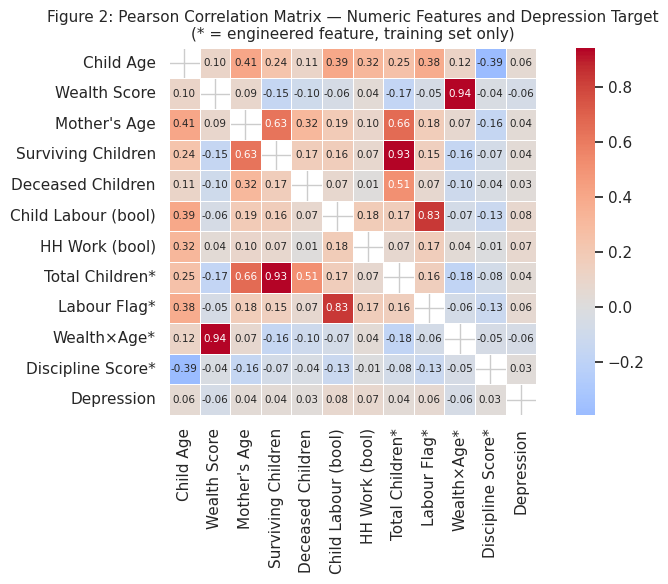

In [12]:
# Figure 2: Correlation heatmap
numeric_for_corr = [
    'CB3', 'wscore', 'WB4', 'CSURV', 'CDEAD', 'CL2', 'CL12',
    'total_children', 'child_labour_flag', 'wealth_age', 'discipline_score'
]
numeric_for_corr = [c for c in numeric_for_corr if c in train_eda.columns]

label_map_corr = {
    'CB3': 'Child Age', 'wscore': 'Wealth Score', 'WB4': "Mother's Age",
    'CSURV': 'Surviving Children', 'CDEAD': 'Deceased Children',
    'CL2': 'Child Labour (bool)', 'CL12': 'HH Work (bool)',
    'total_children': 'Total Children*',
    'child_labour_flag': 'Labour Flag*',
    'wealth_age': 'Wealth×Age*',
    'discipline_score': 'Discipline Score*',
    'depression': 'Depression'
}

corr_df = train_eda[numeric_for_corr + ['depression']].rename(columns=label_map_corr)
corr_matrix = corr_df.corr()
mask = np.eye(len(corr_matrix), dtype=bool)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, linewidths=0.5, square=True, mask=mask,
            annot_kws={'size': 7.5})
ax.set_title(
    'Figure 2: Pearson Correlation Matrix — Numeric Features and Depression Target\n'
    '(* = engineered feature, training set only)', fontsize=11)
plt.tight_layout()
plt.show()

**Figure 2.** Pearson correlation matrix for numeric features and the binary depression target (training set). All individual correlations with the target are weak (|r| <= 0.10), confirming that no single numeric predictor provides strong linear separation. Wealth Score shows the strongest association (r = −0.06), though Pearson r underestimates its true effect given the variable's right-skewed distribution. The `Wealth×Age` interaction is near-perfectly collinear with Wealth Score (r ~ 0.94), which is benign for Random Forest but inflates LR coefficient variance for these two features.

## 2.12 Preprocessing Pipeline

The preprocessing pipeline is constructed using sklearn's `ColumnTransformer` with three parallel sub-pipelines, each fitted exclusively on the training set and then applied to the test set to prevent data leakage.

- **Numeric features** receive median imputation (robust to the right-skewed distributions observed in several survey items such as wealth score and age) followed by standardisation via `StandardScaler`.
- **Ordinal features** receive mode imputation followed by `OrdinalEncoder` with explicitly specified category orderings, preserving the rank structure defined in the ordinal cleaning step above. The `handle_unknown='use_encoded_value'` option assigns unseen categories a sentinel value of −1 rather than raising an error.
- **Nominal features** receive mode imputation followed by `OneHotEncoder` with `drop='first'` to avoid the dummy variable trap in Logistic Regression, and `handle_unknown='ignore'` to silently zero-out any unseen categories at prediction time.

In [13]:
# Define ordered categories for OrdinalEncoder
ORDINAL_CATEGORY_DEFS = {
    'CB5A': ['ECE', 'PRIMARY', 'LOWER SECONDARY', 'UPPER SECONDARY'],
    'CB5B': [f'GRADE {i}' for i in range(1, 9)],
    'WB6A': ['PRIMARY', 'LOWER SECONDARY', 'UPPER SECONDARY', 'HIGHER'],
    'WB6B': [f'GRADE {i}' for i in range(1, 9)],
    'WB14': ['CANNOT READ AT ALL', 'ABLE TO READ ONLY PARTS OF SENTENCE', 'ABLE TO READ WHOLE SENTENCE'],
    'AF10': ['NO DIFFICULTY', 'SOME DIFFICULTY', 'A LOT OF DIFFICULTY'],
    'AF11': ['NO DIFFICULTY', 'SOME DIFFICULTY'],
    'AF12': ['NO DIFFICULTY', 'SOME DIFFICULTY'],
    'LS1':  ['VERY UNHAPPY', 'SOMEWHAT UNHAPPY', 'NEITHER HAPPY NOR UNHAPPY', 'SOMEWHAT HAPPY', 'VERY HAPPY'],
    'LS3':  ['WORSENED', 'MORE OR LESS THE SAME', 'IMPROVED'],
    'LS4':  ['WORSE', 'MORE OR LESS THE SAME', 'BETTER'],
    'VT20': ['VERY UNSAFE', 'UNSAFE', 'SAFE', 'VERY SAFE'],
    'VT21': ['VERY UNSAFE', 'UNSAFE', 'SAFE', 'VERY SAFE']
}
ordinal_categories = [ORDINAL_CATEGORY_DEFS[c] for c in ordinal_cols]

# Build sub-pipelines
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
ordinal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=ordinal_categories,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])
nominal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        drop='first', handle_unknown='ignore', sparse_output=False
    ))
])

# Assemble ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('ord', ordinal_pipe, ordinal_cols),
    ('nom', nominal_pipe, nominal_cols)
], remainder='drop')

# Fit on training set only, transform train and test
preprocessor.fit(X_train)
X_train_proc_full = preprocessor.transform(X_train)
X_test_proc_full  = preprocessor.transform(X_test)

print(f"Processed shapes: train={X_train_proc_full.shape}, test={X_test_proc_full.shape}")
print(f"NaN in X_train_processed: {np.isnan(X_train_proc_full).sum()}")
print(f"NaN in X_test_processed:  {np.isnan(X_test_proc_full).sum()}")

Processed shapes: train=(10805, 113), test=(1893, 113)
NaN in X_train_processed: 0
NaN in X_test_processed:  0


## 2.13 Correlation-Based Feature Selection

Following the preprocessing pipeline, a lightweight Pearson correlation filter is applied to the processed feature matrix. Features whose absolute correlation with the binary target falls below 0.005 are removed. This threshold is calibrated as the product of the maximum individual feature–target correlation (~0.10) and the conventional significance level (0.05), following the approach of Ge and Zhang [8]. The filter is computed solely on the training set to prevent leakage, and the resulting feature index is applied to both partitions.

In [14]:
# Compute Pearson correlations on training set
feature_names = preprocessor.get_feature_names_out()

corr_with_y = pd.Series(
    [np.corrcoef(X_train_proc_full[:, i], y_train)[0, 1]
     for i in range(X_train_proc_full.shape[1])],
    index=feature_names
).fillna(0.0)

low_corr_count = (corr_with_y.abs() < CORR_THRESH).sum()
print(f"Features with |corr| < {CORR_THRESH}: {low_corr_count}  (to be removed)")

# Apply filter
keep_idx = np.where(corr_with_y.abs() >= CORR_THRESH)[0]
X_train_proc = X_train_proc_full[:, keep_idx]
X_test_proc = X_test_proc_full[:, keep_idx]
feature_names_final = feature_names[keep_idx]
corr_final = corr_with_y.iloc[keep_idx]

print(f"\nFeatures retained after filter: {X_train_proc.shape[1]}")
print(f"Final processed shape: train={X_train_proc.shape}, test={X_test_proc.shape}")

Features with |corr| < 0.005: 10  (to be removed)

Features retained after filter: 103
Final processed shape: train=(10805, 103), test=(1893, 103)


# 3. Model Fitting and Tuning

## 3.1 Evaluation Metrics

Four complementary metrics are reported throughout this section.

- **ROC-AUC:** the probability that a randomly chosen depressed child is ranked higher than a randomly chosen non-depressed child. Threshold-independent and robust to the mild class imbalance.
- **Average Precision (AP):** the area under the Precision-Recall curve. Emphasises the model's ability to identify positive cases across all decision thresholds. A random classifier achieves AP equal to the positive-class prevalence (~0.547).
- **Accuracy:** proportion of correct predictions at the default 0.5 threshold.
- **F1:** harmonic mean of precision and recall for the depression class at the 0.5 threshold.

ROC-AUC is the primary optimisation metric for both models.

In [15]:
# Shared evaluation helper
def evaluate_model(y_true, proba, threshold=0.5, name='Model'):
    """Return a dict of four evaluation metrics."""
    pred = (proba >= threshold).astype(int)
    return {
        'Model': name,
        'ROC-AUC': round(roc_auc_score(y_true, proba), 4),
        'Avg Precision': round(average_precision_score(y_true, proba), 4),
        'Accuracy': round(accuracy_score(y_true, pred), 4),
        'F1': round(f1_score(y_true, pred), 4)
    }

print("evaluate_model() helper defined.")

evaluate_model() helper defined.


## 3.2 Baseline Model: Logistic Regression

Logistic Regression with L2 (ridge) regularisation serves as the interpretable baseline. It provides directly readable coefficients by quantifying the log-odds change per unit change in each standardised feature, making it both a performance benchmark and an interpretive complement to the Random Forest. L2 regularisation is retained throughout to stabilise estimates in the presence of the multicollinearity (Figure 2).

The regularisation strength C (where larger C = weaker penalty) is tuned over a six-point log-uniform grid via five-fold stratified cross-validation on the training set, with ROC-AUC as the sole scoring criterion. The value of C that maximises mean CV ROC-AUC is selected. The `max_iter=1000` ensures convergence on the moderately high-dimensional processed feature matrix. The fitted model is then evaluated definitively on the held-out test set.

In [16]:
# Logistic Regression — five-fold stratified CV on training set, tuned on ROC-AUC
lr_base = LogisticRegression(penalty='l2', max_iter=1000, random_state=RANDOM_STATE)
param_grid_lr = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

lr_search = GridSearchCV(
    lr_base, param_grid_lr, cv=5,
    scoring='roc_auc', refit=True,
    n_jobs=-1, verbose=0
)
lr_search.fit(X_train_proc, y_train)

best_C = lr_search.best_params_['C']
best_cv_auc = lr_search.best_score_
print(f"LR Grid Search — Best C: {best_C}  |  Best 5-fold CV ROC-AUC: {best_cv_auc:.4f}")

best_lr = lr_search.best_estimator_
lr_proba_test = best_lr.predict_proba(X_test_proc)[:, 1]
lr_pred_test = best_lr.predict(X_test_proc)

lr_results_test = evaluate_model(y_test, lr_proba_test, name='LR (test)')
print(f"LR Test set — {lr_results_test}")

LR Grid Search — Best C: 0.1  |  Best 5-fold CV ROC-AUC: 0.6431
LR Test set — {'Model': 'LR (test)', 'ROC-AUC': 0.6325, 'Avg Precision': 0.6718, 'Accuracy': 0.5996, 'F1': 0.6555}


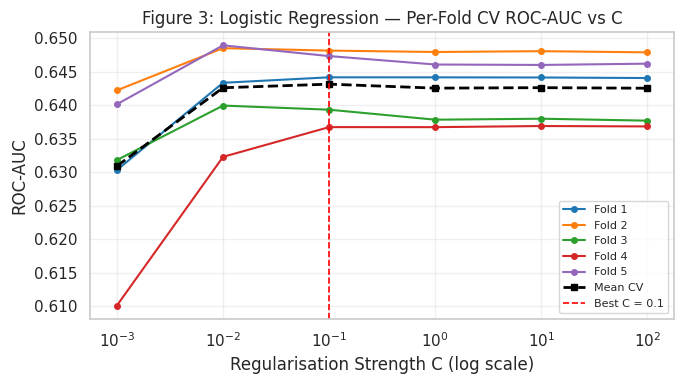

In [17]:
# Figure 3: LR per-fold CV ROC-AUC vs C
cv_df = pd.DataFrame(lr_search.cv_results_)
C_vals = cv_df['param_C'].astype(float).values
fold_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, ax = plt.subplots(figsize=(7, 4))
for fold, color in enumerate(fold_colors):
    scores = cv_df[f'split{fold}_test_score'].values
    ax.plot(C_vals, scores, marker='o', markersize=4,
            color=color, linewidth=1.5, label=f'Fold {fold+1}')

mean_scores = cv_df['mean_test_score'].values
ax.plot(C_vals, mean_scores, marker='s', markersize=5,
        color='black', linewidth=2, linestyle='--', label='Mean CV')
ax.axvline(best_C, color='red', linestyle='--', linewidth=1.2,
           label=f'Best C = {best_C}')
ax.set_xscale('log')
ax.set_xlabel('Regularisation Strength C (log scale)')
ax.set_ylabel('ROC-AUC')
ax.set_title('Figure 3: Logistic Regression — Per-Fold CV ROC-AUC vs C')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Figure 3.** Per-fold cross-validation ROC-AUC for Logistic Regression across six regularisation strengths C (log scale). The five coloured lines represent individual CV folds, the black dashed line shows the mean CV ROC-AUC across folds, the red dashed vertical line marks the selected value of C. Fold scores cluster tightly at each C value, indicating stable generalisation across training partitions.

## 3.3 Final Model: Random Forest

Random Forest [9] is selected as the final model for the following reasons. Firstly, it constructs an ensemble of decision trees that captures non-linear relationships and feature interactions that Logistic Regression cannot represent, which given the complex socioeconomic and familial determinants of childhood depression, such non-linear effects are expected. Secondly, it is naturally robust to the multicollinearity (Figure 2): individual trees are trained on bootstrap samples and random feature subsets, so correlated predictors do not destabilise the ensemble.

**Hyperparameter strategy:** Three hyperparameters are tuned via five-fold stratified cross-validation on the training set, with ROC-AUC as the scoring criterion. Each hyperparameter is swept independently while the remaining two are held at sensible anchor values, and the value yielding the highest mean CV ROC-AUC is selected:

- `n_estimators`: 50, 100, 200, 300 (anchor value), 400, 500
- `max_depth`: 4, 6, 8, 10, 12, unlimited (anchor value)
- `min_samples_leaf`: 1 (anchor value), 2, 5, 10, 20

`max_features='sqrt'` (standard for classification) is fixed throughout. The test set is not consulted at any stage of hyperparameter selection. It is acknowledged that sweeping each hyperparameter independently does not account for potential interactions between them. A full grid search was considered but ruled out on computational grounds given the size of the feature matrix.

In [18]:
# Random Forest — independent per-hyperparameter CV sweeps on training set
skf_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fold_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Hyperparameter ranges to explore
n_est_vals = [50, 100, 200, 300, 400, 500]
depth_vals = [4, 6, 8, 10, 12, None]
msl_vals = [1, 2, 5, 10, 20]

# Anchor values held fixed when sweeping other parameters
ANCHOR_N_EST = 300
ANCHOR_DEPTH = None
ANCHOR_MSL = 1

def sweep_cv_scores(param_vals, param_name, base_kwargs):
    """For each value in param_vals, run 5-fold CV and return per-fold ROC-AUC scores."""
    results = {}
    for val in param_vals:
        kwargs = {**base_kwargs, param_name: val}
        rf_cv  = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **kwargs)
        scores = cross_val_score(
            rf_cv, X_train_proc, y_train,
            cv=skf_rf, scoring='roc_auc', n_jobs=-1
        )
        results[val] = scores
        lbl = 'None' if val is None else val
        print(f"  {param_name}={str(lbl):>6}  mean CV AUC={scores.mean():.4f}  "
              f"folds={scores.round(4)}")
    return results

print("=== Sweeping n_estimators (anchor: max_depth=None, min_samples_leaf=1) ===")
n_est_scores = sweep_cv_scores(
    n_est_vals, 'n_estimators',
    dict(max_depth=ANCHOR_DEPTH, min_samples_leaf=ANCHOR_MSL, max_features='sqrt')
)

print("\n=== Sweeping max_depth (anchor: n_estimators=300, min_samples_leaf=1) ===")
depth_scores = sweep_cv_scores(
    depth_vals, 'max_depth',
    dict(n_estimators=ANCHOR_N_EST, min_samples_leaf=ANCHOR_MSL, max_features='sqrt')
)

print("\n=== Sweeping min_samples_leaf (anchor: n_estimators=300, max_depth=None) ===")
msl_scores = sweep_cv_scores(
    msl_vals, 'min_samples_leaf',
    dict(n_estimators=ANCHOR_N_EST, max_depth=ANCHOR_DEPTH, max_features='sqrt')
)

# Select best value per hyperparameter (highest mean CV ROC-AUC)
best_n_est = max(n_est_vals, key=lambda v: n_est_scores[v].mean())
best_depth = max(depth_vals, key=lambda v: depth_scores[v].mean())
best_msl = max(msl_vals, key=lambda v: msl_scores[v].mean())

print(f"\nSelected hyperparameters (highest mean CV ROC-AUC):")
print(f"  n_estimators    = {best_n_est}  "
      f"(mean CV AUC: {n_est_scores[best_n_est].mean():.4f})")
print(f"  max_depth       = {best_depth}  "
      f"(mean CV AUC: {depth_scores[best_depth].mean():.4f})")
print(f"  min_samples_leaf= {best_msl}   "
      f"(mean CV AUC: {msl_scores[best_msl].mean():.4f})")

=== Sweeping n_estimators (anchor: max_depth=None, min_samples_leaf=1) ===
  n_estimators=    50  mean CV AUC=0.6248  folds=[0.6223 0.6352 0.618  0.6247 0.6235]
  n_estimators=   100  mean CV AUC=0.6398  folds=[0.6402 0.648  0.6279 0.639  0.6438]
  n_estimators=   200  mean CV AUC=0.6486  folds=[0.6443 0.6674 0.6305 0.6504 0.6504]
  n_estimators=   300  mean CV AUC=0.6511  folds=[0.6488 0.6661 0.6309 0.6573 0.6523]
  n_estimators=   400  mean CV AUC=0.6535  folds=[0.6536 0.6696 0.6324 0.6584 0.6535]
  n_estimators=   500  mean CV AUC=0.6535  folds=[0.6525 0.6694 0.6327 0.6602 0.653 ]

=== Sweeping max_depth (anchor: n_estimators=300, min_samples_leaf=1) ===
  max_depth=     4  mean CV AUC=0.6398  folds=[0.6336 0.6619 0.6199 0.653  0.6305]
  max_depth=     6  mean CV AUC=0.6456  folds=[0.6433 0.6656 0.6239 0.6552 0.6397]
  max_depth=     8  mean CV AUC=0.6493  folds=[0.6469 0.6708 0.6265 0.6593 0.643 ]
  max_depth=    10  mean CV AUC=0.6505  folds=[0.6522 0.6716 0.6256 0.6597 0.6433]
  

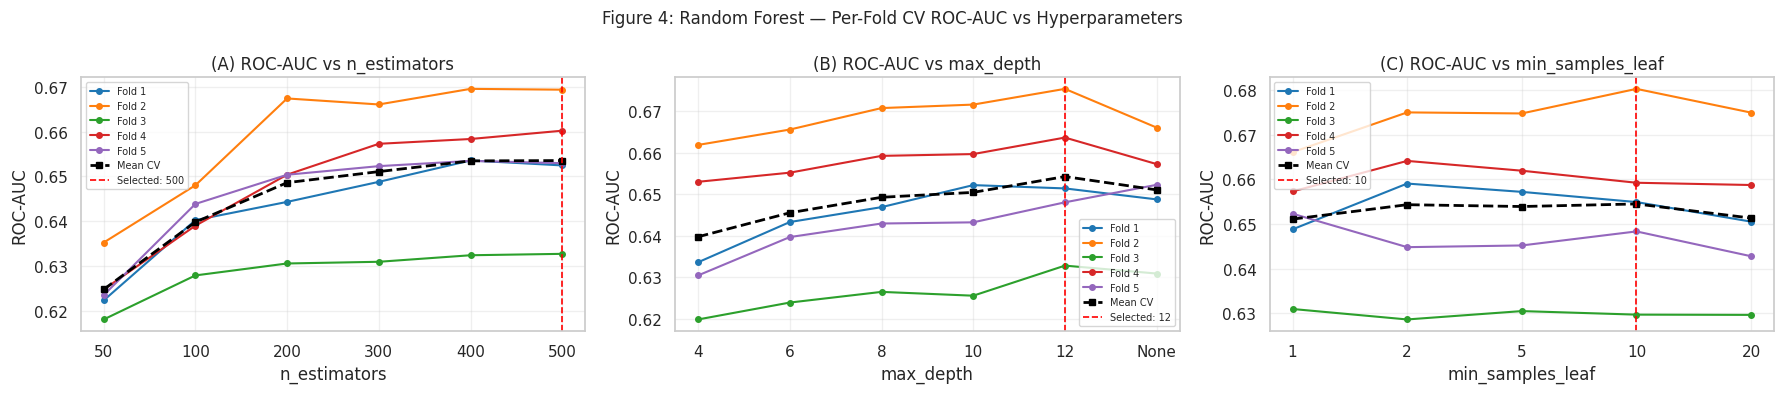

In [19]:
# Figure 4: RF per-fold CV ROC-AUC vs each hyperparameter (3-panel)
x_n_est = [str(v) for v in n_est_vals]
x_depth = [str(d) if d is not None else 'None' for d in depth_vals]
x_msl = [str(v) for v in msl_vals]

best_depth_label = str(best_depth) if best_depth is not None else 'None'

sweep_specs = [
    ('(A)', 'n_estimators', x_n_est, n_est_vals, n_est_scores, str(best_n_est)),
    ('(B)', 'max_depth', x_depth, depth_vals, depth_scores, best_depth_label),
    ('(C)', 'min_samples_leaf', x_msl, msl_vals, msl_scores, str(best_msl))
]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=False)
for ax, (panel, pname, xlabels, pvals, scores_dict, best_lbl) in zip(axes, sweep_specs):
    for fold_i, color in enumerate(fold_colors):
        fold_scores = [scores_dict[v][fold_i] for v in pvals]
        ax.plot(xlabels, fold_scores, marker='o', markersize=4,
                color=color, linewidth=1.5, label=f'Fold {fold_i+1}')
    means = [scores_dict[v].mean() for v in pvals]
    ax.plot(xlabels, means, marker='s', markersize=5,
            color='black', linewidth=2, linestyle='--', label='Mean CV')
    best_idx = xlabels.index(best_lbl)
    ax.axvline(best_idx, color='red', linestyle='--', linewidth=1.2,
               label=f'Selected: {best_lbl}')
    ax.set_xlabel(pname)
    ax.set_ylabel('ROC-AUC')
    ax.set_title(f'{panel} ROC-AUC vs {pname}')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

fig.suptitle('Figure 4: Random Forest — Per-Fold CV ROC-AUC vs Hyperparameters',
             fontsize=12)
plt.tight_layout()
plt.show()

**Figure 4.** Per-fold cross-validation ROC-AUC for the Random Forest as a function of each tuned hyperparameter (five coloured fold lines, black dashed = mean CV ROC-AUC, red dashed vertical = selected value). Each panel sweeps one hyperparameter while the remaining two are fixed at their anchor values. **(A)** `n_estimators`: mean CV ROC-AUC stabilises beyond approximately 200 trees, confirming diminishing returns from adding further trees. The selected value balances stability against computational cost. **(B)** `max_depth`: performance increases monotonically with depth. `max_depth=12` is selected in preference because it constrains tree growth, providing a modest regularisation benefit without sacrificing discriminative performance. **(C)** `min_samples_leaf`: mean CV ROC-AUC is relatively stable across the range tested, confirming that the optimal setting lies in a flat region of the performance surface and that results are not sensitive to the precise value chosen within this neighbourhood.

## 3.4 Final Model Evaluation on Test Set

The tuned Random Forest is refit on the full training set using the hyperparameters selected via cross-validation. Both models are then evaluated on the held-out test set. This is the definitive performance comparison between the baseline Logistic Regression and the final Random Forest model.

In [20]:
# Fit final RF on training set with CV-selected hyperparameters
final_rf = RandomForestClassifier(
    n_estimators=best_n_est,
    max_depth=best_depth,
    min_samples_leaf=best_msl,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
final_rf.fit(X_train_proc, y_train)

# Evaluate both models on TEST set
rf_proba_test = final_rf.predict_proba(X_test_proc)[:, 1]
rf_pred_test = final_rf.predict(X_test_proc)

rf_results_test = evaluate_model(y_test, rf_proba_test, name='Random Forest (test)')

print("=== Final Test Set Results ===")
results_df = pd.DataFrame([lr_results_test, rf_results_test]).set_index('Model')
print(results_df.to_string())

=== Final Test Set Results ===
                      ROC-AUC  Avg Precision  Accuracy      F1
Model                                                         
LR (test)              0.6325         0.6718    0.5996  0.6555
Random Forest (test)   0.6418         0.6790    0.6027  0.6832


Both models demonstrate genuine discriminative ability above chance (ROC-AUC > 0.5, Average Precision substantially above the no-skill baseline, which equals the positive class prevalence). The Random Forest outperforms Logistic Regression across all four metrics, with the largest absolute gain in F1 (0.683 vs 0.656), reflecting its markedly higher sensitivity at the default 0.5 decision threshold. Both models' moderate absolute performance is attributable to the inherent data ceiling (Figure 9).

# 4. Interpretation, Discussion and Conclusions

## 4.1 Feature Importances

Mean Decrease in Impurity (MDI) importances from the final Random Forest quantify the average reduction in node impurity (Gini) achieved by each feature across all trees. Higher values indicate features that consistently provide better splits, accounting for both main effects and interactions. Human-readable labels are assigned to aid policy communication.

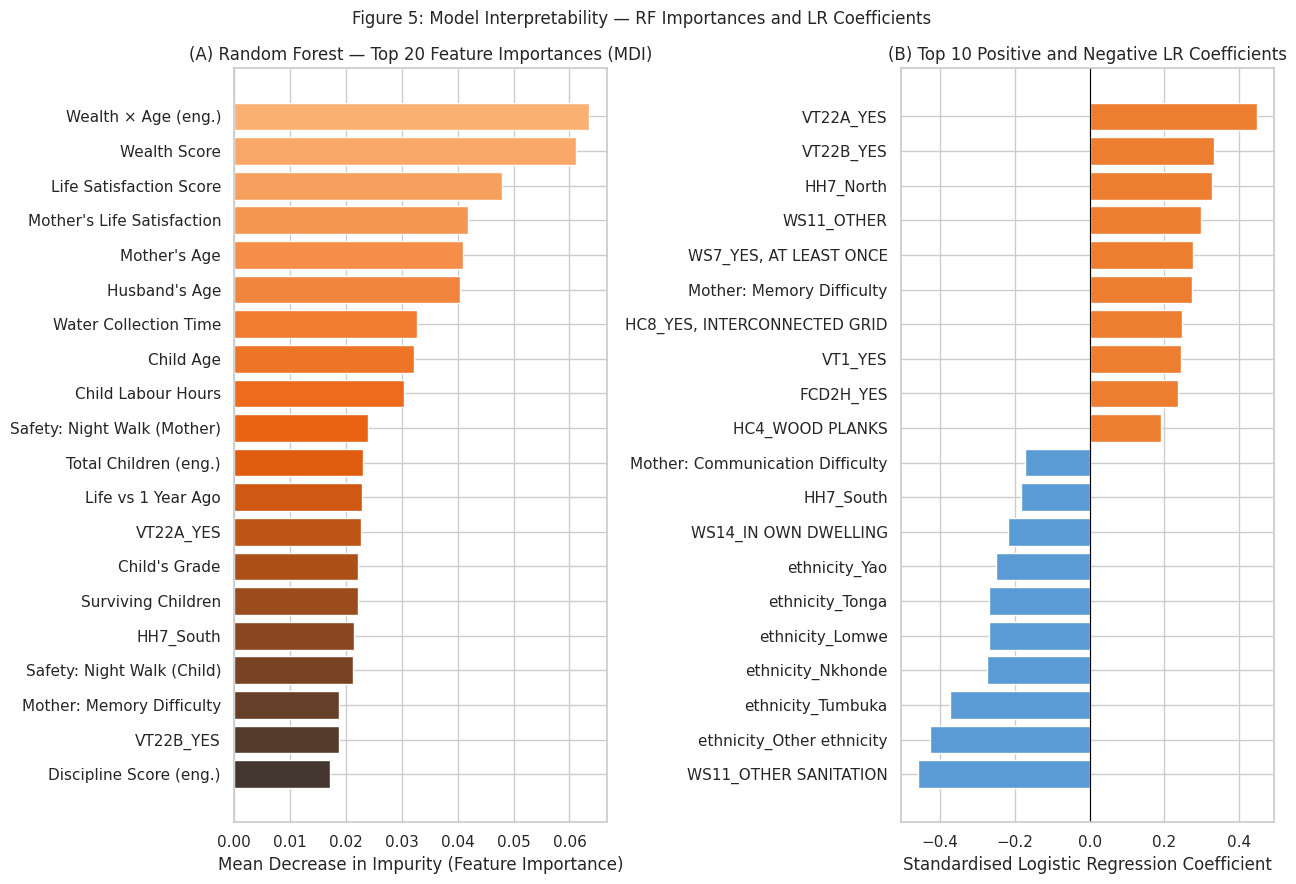

In [21]:
# Figure 5: RF feature importances (top 20) and LR standardised coefficients
LABEL_MAP = {
    'num__CB3': 'Child Age',
    'num__wscore': 'Wealth Score',
    'num__WB4': "Mother's Age",
    'num__CSURV': 'Surviving Children',
    'num__CDEAD': 'Deceased Children',
    'num__CL2': 'Child Engages in Labour',
    'num__CL12': 'Child Does Household Work',
    'num__total_children': 'Total Children (eng.)',
    'num__child_labour_flag': 'Labour Flag (eng.)',
    'num__wealth_age': 'Wealth × Age (eng.)',
    'num__discipline_score': 'Discipline Score (eng.)',
    'num__CL13': 'Child Labour Hours',
    'num__LS2': 'Life Satisfaction Score',
    'num__MA2': "Husband's Age",
    'num__WS4': 'Water Collection Time',
    'ord__LS1': "Mother's Life Satisfaction",
    'ord__LS3': 'Life vs 1 Year Ago',
    'ord__LS4': 'Life vs 1 Year Ahead',
    'ord__WB14': "Mother's Literacy",
    'ord__WB6A': "Mother's Education Level",
    'ord__WB6B': "Mother's Education Grade",
    'ord__CB5A': "Child's School Level",
    'ord__CB5B': "Child's Grade",
    'ord__AF10': 'Mother: Memory Difficulty',
    'ord__AF11': 'Mother: Self-Care Difficulty',
    'ord__AF12': 'Mother: Communication Difficulty',
    'ord__VT20': 'Safety: Night Walk (Mother)',
    'ord__VT21': 'Safety: Night Walk (Child)'
}

importances = pd.Series(
    final_rf.feature_importances_, index=feature_names_final
).sort_values(ascending=False)
top20 = importances.head(20)
labels_20 = [LABEL_MAP.get(f, f.replace('nom__','').replace('ord__','').replace('num__',''))
              for f in top20.index]

coef_series = pd.Series(best_lr.coef_[0], index=feature_names_final)
top_pos = coef_series.nlargest(10)
top_neg = coef_series.nsmallest(10)
combined_lr = pd.concat([top_neg, top_pos]).sort_values()
labels_lr = [LABEL_MAP.get(f, f.replace('nom__','').replace('ord__','').replace('num__',''))
                for f in combined_lr.index]
colors_lr = [ORANGE if v > 0 else BLUE for v in combined_lr.values]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 9))

# Panel A — RF importances
colors_imp = sns.color_palette('Oranges_d', len(top20))[::-1]
ax1.barh(labels_20[::-1], top20.values[::-1], color=colors_imp, edgecolor='white')
ax1.set_xlabel('Mean Decrease in Impurity (Feature Importance)')
ax1.set_title('(A) Random Forest — Top 20 Feature Importances (MDI)')

# Panel B — LR coefficients
ax2.barh(labels_lr, combined_lr.values, color=colors_lr, edgecolor='white')
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Standardised Logistic Regression Coefficient')
ax2.set_title('(B) Top 10 Positive and Negative LR Coefficients')

fig.suptitle('Figure 5: Model Interpretability — RF Importances and LR Coefficients',
             fontsize=12)
plt.tight_layout()
plt.show()

**Figure 5.** Model interpretability outputs for both classifiers. **(A)** Top 20 MDI feature importances from the tuned Random Forest. Wealth Score and the Wealth × Age interaction rank among the top predictors, confirming material deprivation as a central risk factor. Mother's Age, Surviving Children, and Mother's Life Satisfaction appear consistently in the upper tier, consistent with intergenerational transmission of maternal well-being [2]. Discipline Harshness Score, child labour variables, and household infrastructure indicators reflect correlated poverty pathways [5]. **(B)** Top 10 positive (orange, risk-increasing) and negative (blue, protective) standardised Logistic Regression coefficients.

Agreement between panels supports a finding as robust, while divergence signals non-linearity or multicollinearity. Socioeconomic and maternal well-being variables are prominent in both, confirming their reliability. Where they diverge: Wealth Score is absent from the LR top-10 because its coefficient is diluted by collinearity with Wealth × Age (Figure 2). Individual harsh discipline items (e.g. FCD2H, FCD2E) appear in LR but are absorbed into the composite `discipline_score` in the RF ranking.

## 4.2 ROC and Precision-Recall Curves

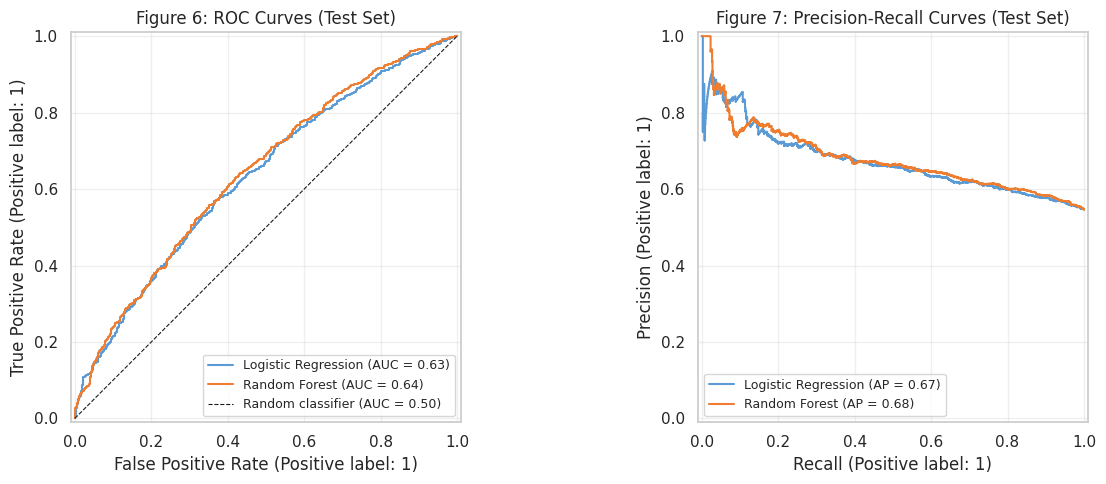

In [22]:
# Figures 6–7: ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Figure 6 — ROC
ax = axes[0]
RocCurveDisplay.from_predictions(
    y_test, lr_proba_test,
    name='Logistic Regression', ax=ax, color=BLUE)
RocCurveDisplay.from_predictions(
    y_test, rf_proba_test,
    name='Random Forest', ax=ax, color=ORANGE)
ax.plot([0,1],[0,1], 'k--', linewidth=0.8, label='Random classifier (AUC = 0.50)')
ax.set_title('Figure 6: ROC Curves (Test Set)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

# Figure 7 — PR
ax = axes[1]
PrecisionRecallDisplay.from_predictions(
    y_test, lr_proba_test,
    name='Logistic Regression', ax=ax, color=BLUE)
PrecisionRecallDisplay.from_predictions(
    y_test, rf_proba_test,
    name='Random Forest', ax=ax, color=ORANGE)
ax.set_title('Figure 7: Precision-Recall Curves (Test Set)')
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Figures 6–7.** Evaluation curves for both models on the held-out test set. **(Figure 6)** ROC curves: both models rise modestly above the diagonal, confirming genuine discriminative ability. The Random Forest achieves modestly higher AUC, though the two curves overlap substantially across the mid-range operating region. **(Figure 7)** Precision-Recall curves: both models substantially exceed the random-classifier baseline, confirming that the models capture real predictive signal. The elevated precision at very low recall (top-left region) indicates that each model can confidently identify a small, high-risk subset, which is a practically important property for a resource-constrained screening programme where only a limited number of referrals can be processed.

## 4.3 Confusion Matrices

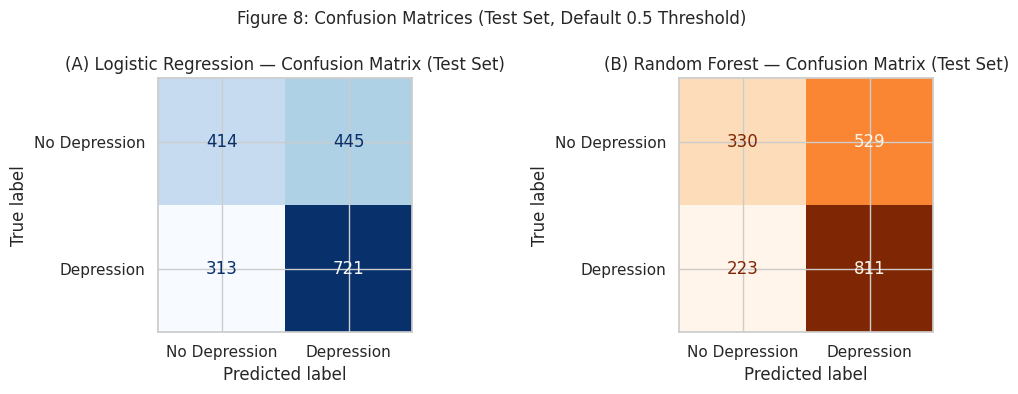

LR: Sensitivity=0.697, Specificity=0.482
RF: Sensitivity=0.784, Specificity=0.384


In [23]:
# Figure 8: Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred_test,
    display_labels=['No Depression', 'Depression'],
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('(A) Logistic Regression — Confusion Matrix (Test Set)')

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred_test,
    display_labels=['No Depression', 'Depression'],
    ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('(B) Random Forest — Confusion Matrix (Test Set)')

fig.suptitle('Figure 8: Confusion Matrices (Test Set, Default 0.5 Threshold)',
              fontsize=12)
plt.tight_layout()
plt.show()

# Print sensitivity and specificity
from sklearn.metrics import confusion_matrix
for name, proba, pred in [('LR', lr_proba_test, lr_pred_test),
                           ('RF', rf_proba_test, rf_pred_test)]:
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    print(f"{name}: Sensitivity={sens:.3f}, Specificity={spec:.3f}")

**Figure 8.** Confusion matrices at the default 0.5 classification threshold for both models on the test set. **(A)** Logistic Regression achieves lower sensitivity (0.697) and higher specificity (0.482) relative to the Random Forest. **(B)** Random Forest achieves higher sensitivity (0.784 vs 0.697) at the cost of lower specificity (0.384 vs 0.482). In a population screening context, this trade-off is preferable: missing a depressed child (false negative) carries greater harm than an unnecessary referral (false positive).

## 4.4 Class-Separability Diagnostic: UMAP Projection

To contextualise the moderate model performance, a UMAP (Uniform Manifold Approximation and Projection) [10] projection of the preprocessed training features is shown below. UMAP preserves local neighbourhood structure while compressing the high-dimensional feature matrix into two dimensions. If the two classes form compact, well-separated clusters in this projection, a well-tuned classifier should achieve high AUC.

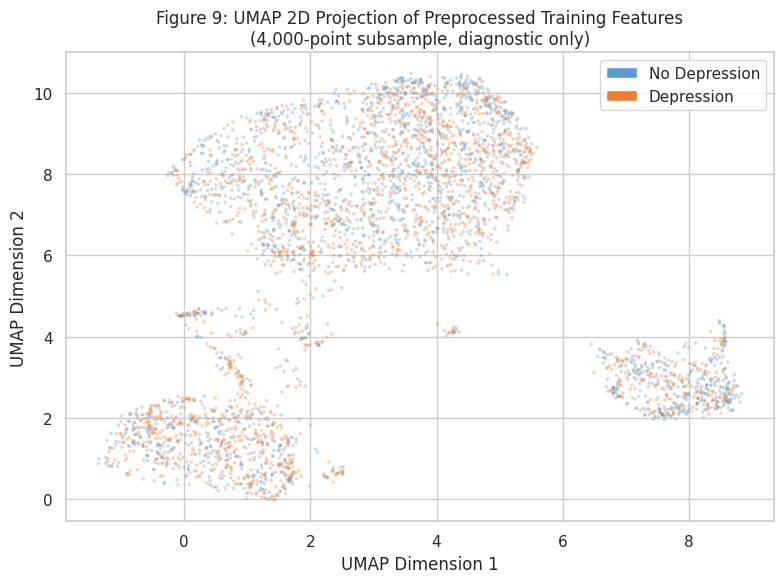

In [24]:
# Figure 9: UMAP class-separability diagnostic
# A fresh UMAP is fitted on the processed training data for visualisation only.
# This does not affect any modelling decisions and is shown for diagnostic purposes.

reducer = umap.UMAP(
    n_components=2, n_neighbors=30, min_dist=0.1,
    metric='euclidean', random_state=RANDOM_STATE, n_jobs=1, verbose=False,
)
X_train_clean = np.nan_to_num(X_train_proc, nan=0.0, posinf=0.0, neginf=0.0)
X_2d = reducer.fit_transform(X_train_clean)

# Subsample 4,000 points for visual clarity (full 8,910 over-plots)
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(len(X_2d), size=min(4000, len(X_2d)), replace=False)
colors_umap = np.where(y_train.values[idx] == 1, ORANGE, BLUE)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_2d[idx, 0], X_2d[idx, 1],
           c=colors_umap, alpha=0.35, s=6, linewidths=0)
handles = [mpatches.Patch(facecolor=BLUE,   label='No Depression'),
           mpatches.Patch(facecolor=ORANGE, label='Depression')]
ax.legend(handles=handles, loc='upper right')
ax.set_title(
    'Figure 9: UMAP 2D Projection of Preprocessed Training Features\n'
    '(4,000-point subsample, diagnostic only)')
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
plt.tight_layout()
plt.show()

**Figure 9.** UMAP 2D projection of the preprocessed training feature matrix (4,000-point random subsample, orange = depressed, blue = not depressed). The two classes are thoroughly intermixed throughout the projection: there are no compact, class-homogeneous clusters visible, and no low-dimensional manifold cleanly separates the two outcomes. This is direct visual evidence that the moderate ROC-AUC ceiling (~0.63–0.64) is a property of the data, not a modelling failure. Depression in children is multiply determined by a complex interplay of individual, familial, and contextual factors, many of which are absent from any single survey instrument.


## 4.5 Discussion

The present analysis demonstrates that a principled machine learning approach applied to population-level survey data can identify meaningful predictors of childhood depression in a sub-Saharan African context. Across both models, three broad thematic domains emerge consistently as drivers of depression risk.

**Socioeconomic deprivation:** Household wealth score and the Wealth × Age interaction rank as the top two predictors in the Random Forest. While these features do not appear in the Logistic Regression top-10 coefficients, their effects are absorbed into each other due to near-perfect collinearity (r = 0.94) and both models consistently assign predictive weight to the wealth domain, confirming material deprivation as a central and robust risk factor. Children in low-wealth households face a constellation of chronic stressors (food insecurity, overcrowding, disrupted schooling, reduced access to healthcare and safe play environments) that collectively elevate internalising disorder risk [2]. The Wealth × Age interaction suggests that these effects compound with developmental stage: older children have had longer cumulative exposure to poverty and are better able to perceive their relative disadvantage, increasing vulnerability. Household infrastructure variables (water source, flooring, roofing) capture additional dimensions of material deprivation and are especially relevant in the Malawian context where rural poverty is spatially concentrated [3]. For policymakers, these findings support wealth-targeted social protection programmes, such as conditional cash transfers, as potential levers for reducing childhood depression at population scale.

**Maternal well-being and family context:** Mother's life satisfaction, mother's age, and the total number of children (surviving and deceased) appear consistently in the upper tier of both models' importance rankings. This pattern is consistent with an intergenerational transmission mechanism: maternal psychological distress, poor self-reported well-being, and high family burden impair caregiving quality, emotional availability, and responsiveness, which in turn elevates child depression risk [2]. The presence of deceased children as a predictor may additionally reflect household exposure to bereavement and the psychological sequelae of recurrent child mortality, a context-specific risk pathway of particular relevance in Malawi, which has historically faced high rates of child mortality. These findings point toward integrated maternal and child health programmes that address maternal mental health not only for its direct benefits but as a child protection strategy.

**Harsh physical discipline:** The engineered discipline harshness score and the individual harsh discipline items (shaking, hitting with an object) feature prominently across both models. This is consistent with the extensive meta-analytic literature documenting a dose-response relationship between harsh physical discipline and children's internalising symptoms, including depression [5]. Even when controlling for wealth and other household factors, discipline practices retain independent predictive value, suggesting that interventions targeting parenting behaviour (e.g. positive parenting programmes that reduce reliance on physical punishment) could yield improvements in child mental health independently of socioeconomic conditions.

Taken together, these three domains suggest that childhood depression in Malawi is best understood as a socially embedded condition, shaped by the intersection of material deprivation, caregiving quality, and disciplinary practices. This has important implications for how screening and prevention resources are allocated: rather than targeting individual child-level characteristics, the strongest signals point toward household and caregiver characteristics that are accessible through routine administrative and survey data.

## 4.6 Limitations

Several limitations of the present analysis warrant acknowledgement.

**Measurement validity:** The target variable is derived from a caregiver's perception of how often the child seems sad or depressed, not from a validated clinical instrument such as the Child Depression Inventory or DSM-based diagnostic interview. This introduces measurement error in both directions: caregivers may under-report depression in cultures where emotional expression is stigmatised, or may conflate normal developmental sadness with clinical depression. Any predictive model trained on this proxy measure inherits its limitations.

**Cross-sectional design:** The MICS survey is cross-sectional, meaning that predictor and outcome variables are measured at the same point in time. This precludes causal inference: while wealth predicts depression, it is equally plausible that having a depressed child increases household economic strain. Longitudinal cohort data would be necessary to establish temporal precedence.

**Missing data:** Despite principled handling of missing values through mode imputation and structural exclusion of high-missingness columns, the informative missingness of several variables, particularly FCD5 (physical punishment, asked conditionally) and MA2 (husband's age, absent for unmarried mothers), is not explicitly modelled.

**Generalisability:** The model is trained and evaluated on a single country survey. Malawi's specific socioeconomic profile, ethnic composition, and cultural context may limit the generalisability of the estimated feature importances to other LMICs, even those with comparable overall development indicators.

## 4.7 Recommendations and Future Directions

The consistent signals across both models yield clear evidence-based recommendations. For **policymakers**, household socioeconomic indicators, particularly wealth score and access to improved water, sanitation, and housing, should be incorporated into child mental health risk-stratification frameworks, with social protection programmes such as conditional cash transfers considered as potential co-benefit levers. For **healthcare workers**, simple maternal well-being assessments integrated into existing child health contact points (vaccination visits, growth monitoring, antenatal care) could identify high-risk mother–child dyads early. For **parenting programmes**, evidence-based positive discipline interventions that reduce reliance on physical punishment are indicated by both the raw data patterns and the model importances.

**Future research** should: (1) deploy a longitudinal follow-up of the MICS cohort to establish temporal ordering between key predictors and depression onset, (2) validate the binarisation threshold against clinically validated screening instruments in a Malawian subsample, (3) test external validity on MICS datasets from comparable LMICs such as Zimbabwe, Zambia, or Mozambique, and (4) explore ordinal regression models preserving the five-level response structure for finer-grained risk stratification.


# 5. Generative AI Statement

Generative AI tools were used in the following ways: (1) to assist with refining the narrative sections of the report, and (2) to assist in identifying code errors and improving code readability.

# 6. References

1. Pedregosa F, Varoquaux G, Gramfort A, Michel V, Thirion B, Grisel O, et al. Scikit-learn: Machine Learning in Python. *J Mach Learn Res*. 2011;12:2825–30. Available from: http://jmlr.org/papers/v12/pedregosa11a.html

2. Patel V, Saxena S, Lund C, Thornicroft G, Baingana F, Bolton P, et al. The Lancet Commission on global mental health and sustainable development. *Lancet*. 2018;392(10157):1553–98. doi:10.1016/S0140-6736(18)31612-X

3. Malawi National Statistical Office and UNICEF. *Malawi Multiple Indicator Cluster Survey 2019–2020, Survey Findings Report*. Lilongwe: NSO and UNICEF; 2020. Available from: https://mics.unicef.org/surveys

4. UNICEF. Multiple Indicator Cluster Surveys (MICS) [Internet]. New York: UNICEF; 2024 [cited 2025 Mar]. Available from: https://mics.unicef.org/

5. Gershoff ET, Grogan-Kaylor A. Spanking and child outcomes: old controversies and new meta-analyses. *J Fam Psychol*. 2016;30(4):453–69. doi:10.1037/fam0000191

6. Madley-Dowd P, Hughes R, Tilling K, Heron J. The proportion of missing data should not be used to guide decisions on multiple imputation. *J Clin Epidemiol*. 2019;110:63–73. doi:10.1016/j.jclinepi.2019.02.016

7. Marino M, Lucas J, Latour E, Heintzman JD. Missing data in primary care research: importance, implications and approaches. *Fam Pract*. 2021;38(2):199–202. doi:10.1093/fampra/cmaa134

8. Ge G, Zhang J. Feature selection methods and predictive models in CT lung cancer radiomics. *J Appl Clin Med Phys*. 2023;24(1):e13869. doi:10.1002/acm2.13869

9. Breiman L. Random forests. *Mach Learn*. 2001;45(1):5–32. doi:10.1023/A:1010933404324

10. McInnes L, Healy J, Saul N, Großberger L. UMAP: Uniform Manifold Approximation and Projection. *J Open Source Softw*. 2018;3(29):861. doi:10.21105/joss.00861


In [25]:
# Run the following to render to PDF
!jupyter nbconvert --to latex B300238_B296110_MachineLearninginPython_ICA.ipynb
!sed -i 's/\\usepackage{geometry}/\\usepackage[margin=1in]{geometry}/' B300238_B296110_MachineLearninginPython_ICA.tex
!sed -i 's/\\begin{document}/\\usepackage{fontsize}\n\\changefontsize{9pt}\n\\begin{document}/' B300238_B296110_MachineLearninginPython_ICA.tex
!xelatex B300238_B296110_MachineLearninginPython_ICA.tex

[NbConvertApp] Converting notebook B300238_B296110_MachineLearninginPython_ICA.ipynb to latex
[NbConvertApp] Support files will be in B300238_B296110_MachineLearninginPython_ICA_files/
[NbConvertApp] Writing 187181 bytes to B300238_B296110_MachineLearninginPython_ICA.tex
This is XeTeX, Version 3.141592653-2.6-0.999995 (TeX Live 2023/Debian) (preloaded format=xelatex)
 restricted \write18 enabled.
entering extended mode
(./B300238_B296110_MachineLearninginPython_ICA.tex
LaTeX2e <2023-11-01> patch level 1
L3 programming layer <2024-01-22>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2023/05/17 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size11.clo))
(/usr/share/texlive/texmf-dist/tex/latex/tcolorbox/tcolorbox.sty
(/usr/share/texlive/texmf-dist/tex/latex/pgf/basiclayer/pgf.sty
(/usr/share/texlive/texmf-dist/tex/latex/pgf/utilities/pgfrcs.sty
(/usr/share/texlive/texmf-dist/tex/generic/pgf/utilities/pgfutil-common.te